# 11. Study cohort and data quality

This notebook documents **which contracts enter the survival study and what is
known about them**. It presents evidence only; the cohort itself is built by
`scripts/build_survival_cohort.py` so that it is reproducible without running a
notebook.

A cohort row is one procurement *episode* satisfying three conditions:

1. the contracting buyer's structured postal address is in Grand Ouest;
2. at least one CPV code falls in a digital division (32, 35, 48, 72);
3. the episode contains an award notice (`ATTRIBUTION`).

The third condition is what makes a row a **contract** rather than a tender
that may never have been awarded, and it supplies time zero for survival
analysis: the earliest award-notice publication date.

## 1. Reproducible setup

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def find_project_root() -> Path:
    path = Path.cwd().resolve()
    for candidate in [path, *path.parents]:
        if (candidate / "boamp_pipeline").is_dir():
            return candidate
    raise RuntimeError("project root not found")


PROJECT_ROOT = find_project_root()
PROCESSED = PROJECT_ROOT / "data" / "processed" / "boamp"
FIGURES = PROCESSED / "figures" / "cohort_and_data_quality"
FIGURES.mkdir(parents=True, exist_ok=True)

# Categorical slots 1-4 of the reference palette, used in fixed order so a
# segment keeps its colour across every figure in the report.
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]
INK, MUTED, GRID = "#0b0b0b", "#52514e", "#d8d7d2"

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 150,
    "savefig.bbox": "tight",
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.titleweight": "600",
    "axes.labelcolor": MUTED,
    "axes.edgecolor": GRID,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": GRID,
    "grid.linewidth": 0.6,
    "grid.alpha": 0.7,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "text.color": INK,
    "legend.frameon": False,
})


def save(fig, name):
    path = FIGURES / name
    fig.savefig(path)
    print(f"saved {path.relative_to(PROJECT_ROOT)}")


def load_json(name):
    return json.loads((PROCESSED / name).read_text(encoding="utf-8"))


In [2]:
cohort = pd.read_parquet(PROCESSED / "survival_cohort.parquet")
summary = load_json("survival_cohort_summary.json")

print(f"cohort rows        : {len(cohort):,}")
print(f"unique episodes    : {cohort['episode_id'].nunique():,}")
print(f"study cutoff       : {summary['study_cutoff']}")
print(f"cohort version     : {summary['cohort_version']}")
print(f"validation passed  : {summary['validation_passed']}")

cohort rows        : 3,800
unique episodes    : 3,800
study cutoff       : 2025-12-31
cohort version     : boamp_survival_cohort_v1.0
validation passed  : True


## 2. Selection funnel

Every exclusion is counted rather than silently applied. The two small losses
are recorded for honesty: 26 episodes carry an award nature but no award notice
that resolves inside the Grand Ouest notice file, and none were awarded after
the cutoff.

,episodes
stage,
grand_ouest_episodes,144269
digital_cpv,7376
digital_with_award_notice,3826
dropped_unresolved_award_date,26
dropped_awarded_after_cutoff,0
cohort_rows,3800


saved data/processed/boamp/figures/cohort_and_data_quality/01_selection_funnel.png


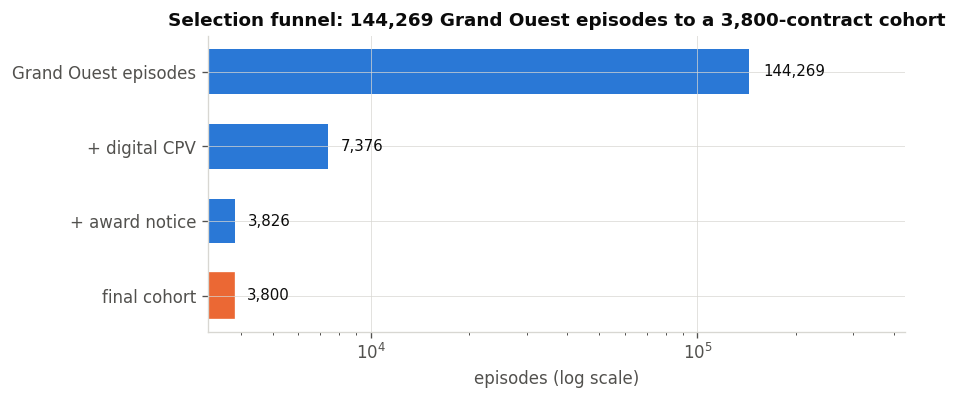

In [3]:
funnel = summary["selection_funnel"]
funnel_frame = pd.DataFrame(
    {"stage": list(funnel.keys()), "episodes": list(funnel.values())}
).set_index("stage")
display(funnel_frame)

steps = [
    ("Grand Ouest episodes", funnel["grand_ouest_episodes"]),
    ("+ digital CPV", funnel["digital_cpv"]),
    ("+ award notice", funnel["digital_with_award_notice"]),
    ("final cohort", funnel["cohort_rows"]),
]
fig, ax = plt.subplots(figsize=(7.5, 3.2))
labels = [s[0] for s in steps]
values = [s[1] for s in steps]
bars = ax.barh(labels, values, color=PALETTE[0], height=0.6)
bars[-1].set_color(PALETTE[1])
ax.set_xscale("log")
ax.set_xlabel("episodes (log scale)")
ax.set_title("Selection funnel: 144,269 Grand Ouest episodes to a 3,800-contract cohort")
ax.invert_yaxis()
for bar, value in zip(bars, values):
    ax.text(value * 1.1, bar.get_y() + bar.get_height() / 2, f"{value:,}",
            va="center", color=INK, fontsize=9)
ax.set_xlim(right=max(values) * 3)
save(fig, "01_selection_funnel.png")
plt.show()

The funnel is steep by design. Restricting 144,269 Grand Ouest episodes to
those with a digital CPV removes 95% of the corpus, and requiring an award
notice removes roughly half of what remains. The result still clears the
guideline's minimum of 800 contracts with an observed or censored duration by a
factor of more than four.

## 3. Cohort composition

Composition matters for the stratified survival curves later: a segment with
too few contracts cannot support its own Kaplan-Meier curve.

saved data/processed/boamp/figures/cohort_and_data_quality/02_cohort_composition.png


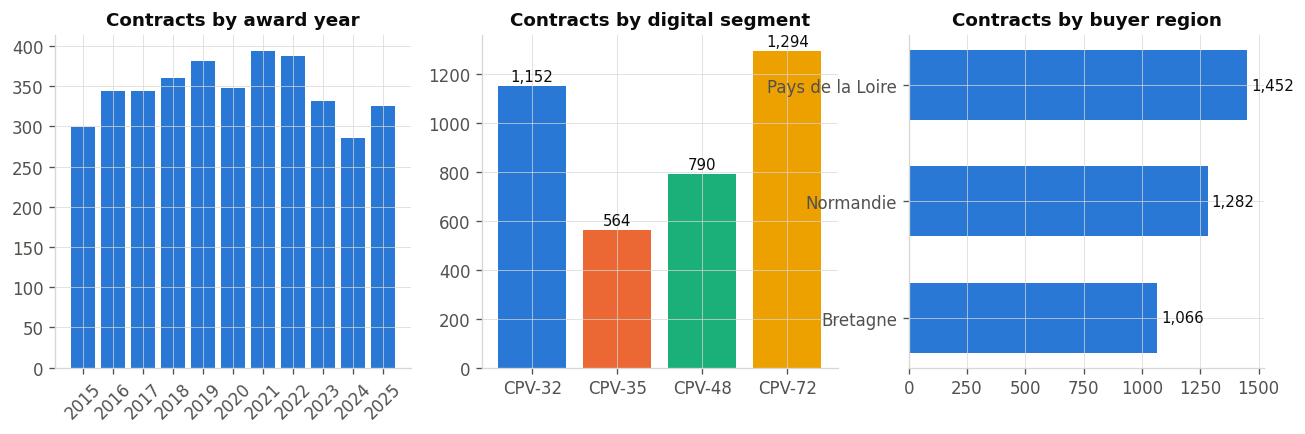

,contracts
segment,
CPV-32,1152
CPV-35,564
CPV-48,790
CPV-72,1294


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))

by_year = cohort["award_year"].value_counts().sort_index()
axes[0].bar(by_year.index.astype(str), by_year.values, color=PALETTE[0])
axes[0].set_title("Contracts by award year")
axes[0].tick_params(axis="x", rotation=45)

by_segment = cohort["digital_segment"].value_counts().sort_index()
axes[1].bar(by_segment.index, by_segment.values,
            color=[PALETTE[i] for i in range(len(by_segment))])
axes[1].set_title("Contracts by digital segment")
for i, (name, value) in enumerate(by_segment.items()):
    axes[1].text(i, value + 20, f"{value:,}", ha="center", color=INK, fontsize=9)

by_region = cohort["buyer_region"].value_counts()
axes[2].barh(by_region.index, by_region.values, color=PALETTE[0], height=0.6)
axes[2].set_title("Contracts by buyer region")
axes[2].invert_yaxis()
for i, (name, value) in enumerate(by_region.items()):
    axes[2].text(value + 15, i, f"{value:,}", va="center", color=INK, fontsize=9)

for ax in axes:
    ax.set_ylabel("")
save(fig, "02_cohort_composition.png")
plt.show()

display(pd.DataFrame({
    "segment": by_segment.index, "contracts": by_segment.values,
}).set_index("segment"))

Volume is stable across the eleven award years, so the cohort is not dominated
by any single period. All four digital segments carry enough contracts to be
analysed separately, and the three regions are represented in proportions
consistent with their public-sector size.

## 4. Missing values

The governing rule is that **missing evidence is not negative evidence**. No
variable below is imputed. Each is either used where present, or explicitly
excluded from the analysis that would have needed it.

,present,missing,missing_pct
duration_months,953.0,2847.0,74.9
duration_months_reliable,953.0,2847.0,74.9
buyer_siren,1279.0,2521.0,66.3
amount_candidates_json,3204.0,596.0,15.7
buyer_name_normalized,3800.0,0.0,0.0
main_cpv,3800.0,0.0,0.0
episode_text,3800.0,0.0,0.0
award_date,3800.0,0.0,0.0
procedure_type,3800.0,0.0,0.0
framework_flag,3800.0,0.0,0.0


saved data/processed/boamp/figures/cohort_and_data_quality/03_variable_completeness.png


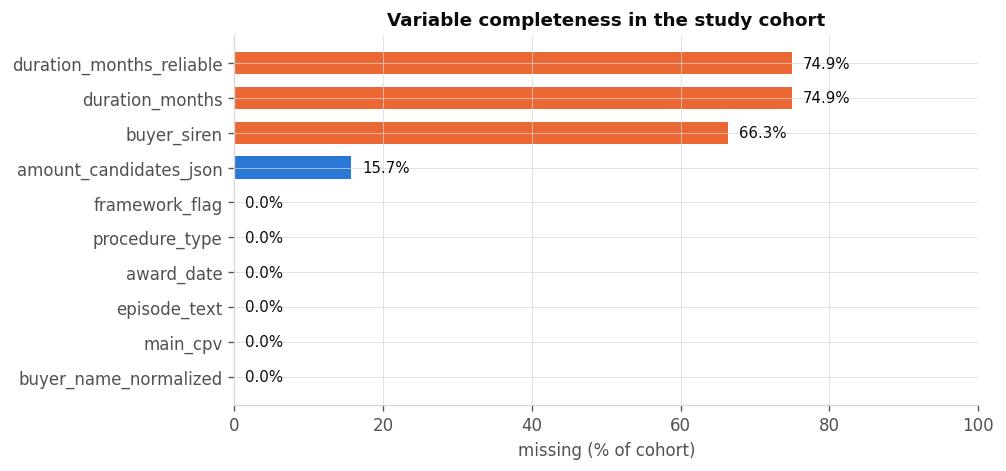

In [5]:
missing = pd.DataFrame(summary["missingness"]).T
missing["missing_pct"] = (missing["missing_rate"] * 100).round(1)
missing = missing.sort_values("missing_rate", ascending=False)
display(missing[["present", "missing", "missing_pct"]])

fig, ax = plt.subplots(figsize=(8, 4))
ordered = missing.sort_values("missing_rate")
colors = [PALETTE[1] if rate > 0.5 else PALETTE[0] for rate in ordered["missing_rate"]]
ax.barh(ordered.index, ordered["missing_rate"] * 100, color=colors, height=0.65)
ax.set_xlabel("missing (% of cohort)")
ax.set_xlim(0, 100)
ax.set_title("Variable completeness in the study cohort")
for i, rate in enumerate(ordered["missing_rate"] * 100):
    ax.text(rate + 1.5, i, f"{rate:.1f}%", va="center", color=INK, fontsize=9)
save(fig, "03_variable_completeness.png")
plt.show()

Two variables are substantially incomplete, and each one drives an explicit
methodological decision rather than an imputation:

| Variable | Missing | Decision |
|---|---|---|
| `duration_months` | ~75% | Only a `typed_consensus` duration is treated as reliable. Where it is absent, **no expected contract end is derived** and the timing evidence for that contract is recorded as unobservable. It is *not* replaced with a default four-year contract. |
| `buyer_siren` | ~66% | Where no Luhn-validated SIREN exists, buyer identity falls back to an exact normalised-name match. Two *unknown* identifiers never count as a match. |
| `amount_candidates_json` | ~16% | Excluded from linkage entirely: a BOAMP amount may be an estimate, a ceiling, an award value, or a single lot, and the field cannot be disambiguated. |

The duration field deserves emphasis because the previous iteration of this
pipeline substituted an assumed four-year contract whenever the duration was
unknown. That converts a missing value into the single most influential timing
input for three quarters of the cohort. The current implementation returns an
explicit missing marker instead (`boamp_pipeline.linkage.time_plausibility_score`),
and the combined linkage score renormalises over whatever evidence genuinely
exists.

In [6]:
quality = pd.DataFrame({
    "duration_quality": pd.Series(summary["rows_by_duration_quality"]),
    "buyer_id_quality": pd.Series(summary["rows_by_buyer_id_quality"]),
})
display(quality)

follow_up = summary["follow_up_days"]
print("follow-up days from award to cutoff: "
      f"min {follow_up['min']}, median {follow_up['median']}, max {follow_up['max']}")

,duration_quality,buyer_id_quality
conflict,5.0,NaN
name_only,NaN,2521.0
trusted_siren,NaN,1279.0
typed_consensus,953.0,NaN
unresolved,2842.0,NaN


follow-up days from award to cutoff: min 0, median 2015, max 3956


## 5. Evidence / Decision

**What was tested.** Whether a defensible study cohort can be drawn from the v2
episode layer, and how complete the variables that the linkage and survival
stages depend on actually are.

**What data were used.** `episodes_grand_ouest.parquet` (144,269 episodes) and
`notices_grand_ouest.parquet` for award dates, both from the validated
`boamp_episode_reconstruction_v1.0` layer.

**Main quantitative results.** 3,800 contracts, spread evenly across 2015-2025,
across three regions and four digital segments, each segment holding at least
564 contracts. Buyer name, CPV and text are essentially complete. Reliable
duration is available for 25% of contracts and a validated SIREN for 34%.

**What the diagnostics show.** The cohort is large enough that no survival
requirement in the guideline is binding. The two badly incomplete variables are
exactly the ones that most tempt imputation, and both have been handled by
explicit exclusion rather than substitution.

**What problems remain.** Missing durations mean the timing component of the
linkage score is unobservable for most pairs, so linkage leans more heavily on
buyer identity and text. Whether that biases which contracts get linked is
measured in notebook 12, not assumed here.

**Decision.** The cohort is frozen as `survival_cohort.parquet`
(`boamp_survival_cohort_v1.0`) with the study cutoff at 2025-12-31.

**Can the next stage proceed?** Yes. Candidate generation and linkage run
against this cohort in notebook 12.